# MA 연습

# 4.4.1 Simulate a MA(2) process and make forecasts

$$y_t = 0.9\theta_{t-1} + 0.3\theta{t-2}$$

In [ ]:
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np 

np.random.seed(42)

ma2 = np.array([1, 0.9, 0.3]) # 1: 현재 오차항 epsilon_t의 계수 (항상 1로 고정); 
# 0.9: 1시차 전 오차항의 계수
# 0.3: 2시차 전 오차항의 계수
ar2 = np.array([1, 0, 0]) # 1: 현재 오차항 epsilon_t의 계수 (AR다항식)

MA2_process = ArmaProcess(ar2, ma2).generate_sample(nsample = 1000)

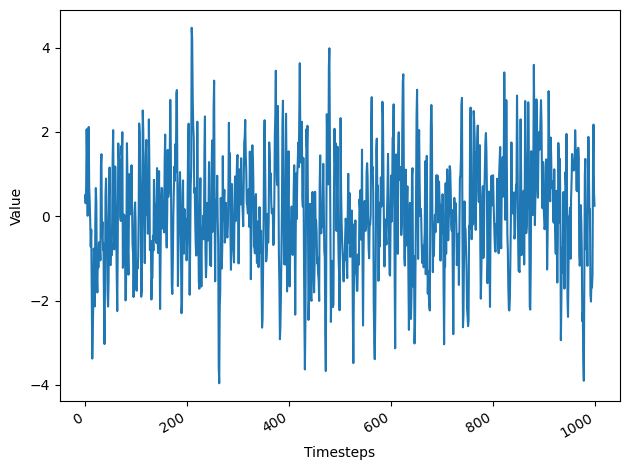

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(MA2_process)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

fig.autofmt_xdate()
plt.tight_layout()

In [3]:
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(MA2_process)

print(f"ADF Stats: {ADF_result[0]}")
print(f"p-val: {ADF_result[1]}")

ADF Stats: -14.005444309194479
p-val: 3.795601616713746e-26


Interpretation:
- stationary

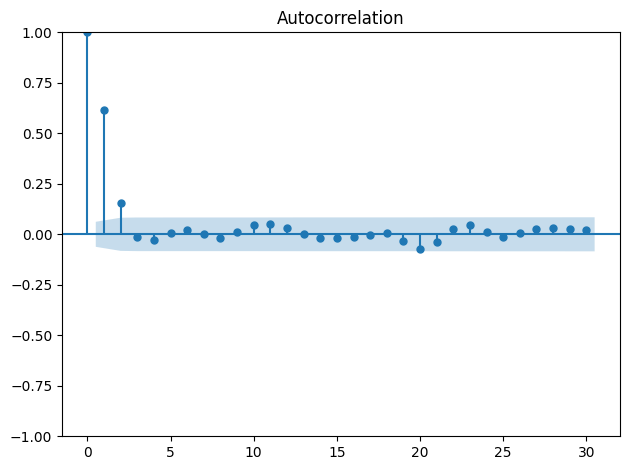

In [4]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(MA2_process, lags = 30)

plt.tight_layout()

After lag = 2, no any significant coefficients

## Split into train and test
- first 800 as train, and the rest as test

In [5]:
import pandas as pd

df = pd.DataFrame({'value': MA2_process})

train = df[:800]
test = df[800:]

Prepare for forecasting based on three methods in rolling forecast:
 - mean
 - last value
 - MA

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, 
                     window: int, method: str) -> list:
    
    total_len = train_len + horizon
    
    if method == 'mean':
        pred_mean = []
        
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))

        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'MA':
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_MA.extend(oos_pred)
            
        return pred_MA

In [11]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA2 = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'MA')

test.loc[:, 'pred_mean'] = pred_mean
test.loc[:, 'pred_last_value'] = pred_last_value
test.loc[:, 'pred_MA2'] = pred_MA2

test.head()

,value,pred_mean,pred_last_value,pred_MA2
800,0.973560,-0.017430,0.259693,0.065366
801,0.337338,-0.017430,0.259693,0.017984
802,-0.086834,-0.015752,0.337338,-0.180397
803,-0.530580,-0.015752,0.337338,-0.116820
804,-0.821708,-0.016481,-0.530580,-0.405768


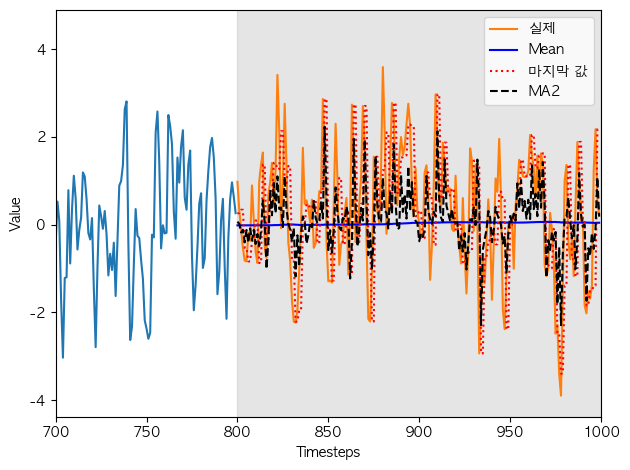

In [16]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
ig, ax = plt.subplots()

ax.plot(train)
ax.plot(test['value'], label='실제')
ax.plot(test['pred_mean'], 'b-', label='Mean')
ax.plot(test['pred_last_value'], 'r:', label='마지막 값')
ax.plot(test['pred_MA2'], 'k--', label='MA2')

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

ax.legend(loc='best')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)

plt.xlim(700, 1000)
fig.autofmt_xdate()
plt.tight_layout()

## Measure MSE

In [17]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last_value'])
mse_MA = mean_squared_error(test['value'], test['pred_MA2'])

print(mse_mean, mse_last, mse_MA)

1.8635013982365882 1.988201688527919 1.2323542190554584


MA(2) has the lowest MSE --> champion model

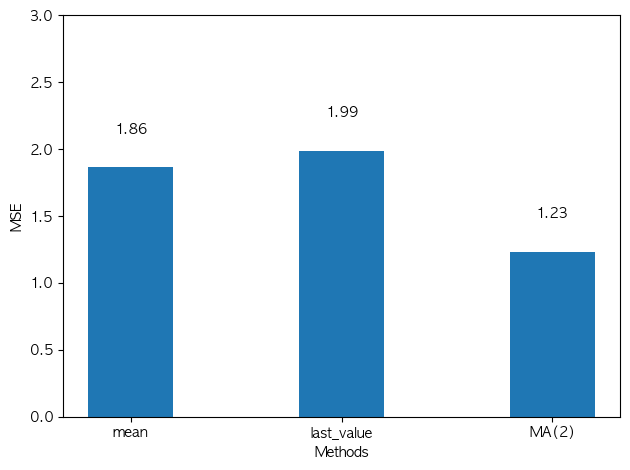

In [18]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 3)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

# 4.4.2 Simulate a MA(q) process and make forecasts

In [ ]:
np.random.seed(42)

ma3 = np.array([1, 0.9, 0.3, 0.2])
#theta가 3개
# 대부분 theta는 줄어드나, 항상 감소해야 하는것은 아님.
# 어떤 값이 되든 MA(3) 프로세스는 성립함.
ar3 = np.array([1, 0, 0, 0])

MA3_process = ArmaProcess(ar3, ma3).generate_sample(nsample=10000)